In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
# plt.style.use('ggplot')
# params = {'legend.fontsize': 'x-large',
#         'figure.figsize': (12, 8),
#         'axes.labelsize': 'x-large',
#         'axes.titlesize':'x-large',
#         'xtick.labelsize':'x-large',
#         'ytick.labelsize':'x-large'}
# pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

In [2]:
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE, plot_overnight_forward_curves
from MDP.STIRFutures.BARCHART.BarchartFetcher import BarchartFetcher

from BT.misc import ql_cal_date_range

In [3]:
from MDP.IRSwaptions.GSQUANT.ql.grid import get_atmf_grid

In [4]:
bc_stirf_curve = BARCHART_STIRF_CURVE()
stirf_mdp = STIRFutureMDP(source="BARCHART_TOS_LIVE_STIRF-RL")
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")
# stirfo_mdp = STIRFutureOptionMDP(source="STIRFO_DUAL-QL")

In [5]:
# out = stirfo_mdp.get_pricer({
#     # "endpoint": "option_snapshot",
#     "endpoint": "option_snapshot",
#     "symbols": ["SFRZ26|9818C"],
#     "timestamp": datetime.date(2026, 3, 5),
#     "show_tqdm": True,
#     "use_ql_calculator": True,
# 	"force_refresh": True
# })
# out
# p = next(iter(out.values()))[0]
# print("price:", p.price())
# print("iv_normal_bps:", p.iv_normal_bps())
# print("delta/gamma/vega/theta:", p.delta(), p.gamma(), p.vega(), p.theta())

# out = stirfo_mdp.get_pricer({
#     # "endpoint": "option_snapshot",
#     "endpoint": "option_snapshot",
#     "symbols": ["SFRZ26|5DC"],
#     "timestamp": datetime.date(2026, 3, 5),
#     "show_tqdm": True,
#     "use_ql_calculator": True,
# 	"force_refresh": True
# })
# out
# p = next(iter(out.values()))[0]
# print("price:", p.price())
# print("iv_normal_bps:", p.iv_normal_bps())
# print("delta/gamma/vega/theta:", p.delta(), p.gamma(), p.vega(), p.theta())

# out = stirfo_mdp.get_pricer({
#     "endpoint": "qs_timeseries",
#     "start": datetime.date(2026, 1, 2),
#     "end": datetime.date(2026, 3, 5),
#     "queries": [
#         {"globex_symbol": "SR3_60", "qv_value_type": "Call", "delta": 50},
#         {"globex_symbol": "SR3_60", "qv_value_type": "Put", "delta": 50},
#     ],
#     "force_refresh": True,  
# 	# "options": True,
# })

smile = stirfo_mdp.fetch_sabr_smile(
    {
        "symbol": "SFRZ26",
        "as_of": datetime.date(2026, 3, 5),
        "force_refresh": True,
        "show_tqdm": True,
    }
)
smile 

FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 55/55 [00:02<00:00, 25.09it/s]


STIRFutureOptionSABRSmile(source='BARCHART_STIRFO-QL', symbol='SFRZ26', underlying_contract='SFRZ26', quote_timestamp=datetime.datetime(2026, 3, 5, 17, 0, tzinfo=<DstTzInfo 'America/New_York' EST-1 day, 19:00:00 STD>), params=STIRFutureOptionSABRParams(alpha=0.06965601678104633, beta=0.5, rho=0.40220517875370015, nu=0.8899873698649847, forward_price=96.67, forward_rate=3.3299999999999983, time_to_expiry=0.7835616438356164, expiry_date=datetime.date(2026, 12, 16), as_of=datetime.date(2026, 3, 5)), points=(STIRFutureOptionSmilePoint(label='SFRZ26|5DP', right='P', delta_abs=5.0, strike_price=95.5413488193117, strike_rate=4.458651180688307, iv_normal_price=0.775168112384299, iv_normal_bps=77.5168112384299), STIRFutureOptionSmilePoint(label='SFRZ26|10DP', right='P', delta_abs=10.0, strike_price=95.8829853337632, strike_rate=4.117014666236798, iv_normal_price=0.6937614370830438, iv_normal_bps=69.37614370830438), STIRFutureOptionSmilePoint(label='SFRZ26|15DP', right='P', delta_abs=15.0, strik

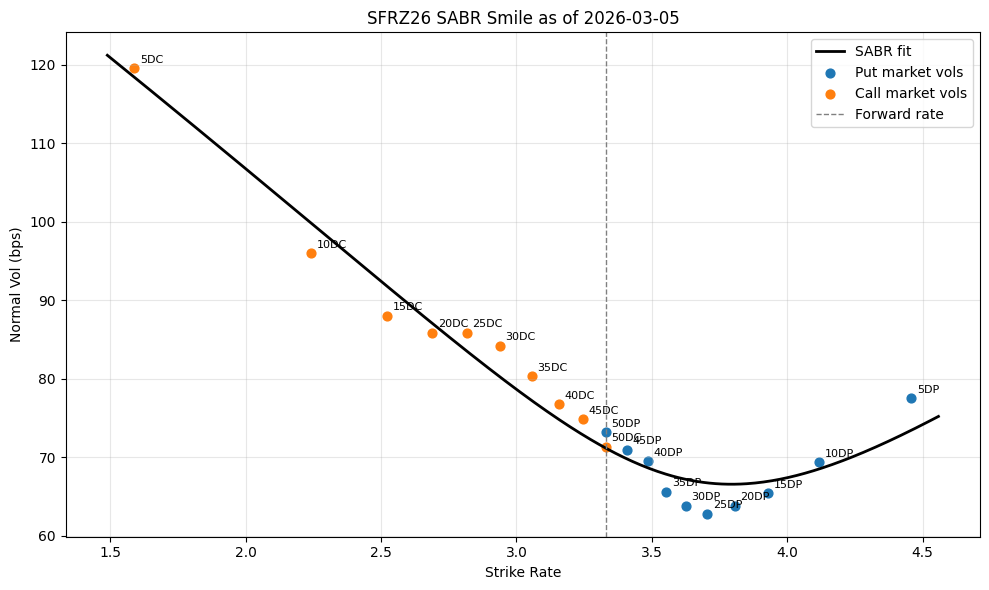

In [7]:
import numpy as np
import matplotlib.pyplot as plt

pts = sorted(smile.points, key=lambda p: p.strike_rate)
call_pts = [p for p in pts if p.right == "C"]
put_pts = [p for p in pts if p.right == "P"]

# Smooth strike grid in rate space
x_min = min(p.strike_rate for p in pts) - 0.10
x_max = max(p.strike_rate for p in pts) + 0.10
strike_grid = np.linspace(x_min, x_max, 400)

# Model vols from fitted SABR smile
sabr_vols_bps = smile.normal_vol(
    strike_grid,
    strike_space="rate",
    vol_units="bps",
)

fig, ax = plt.subplots(figsize=(10, 6))

# Smooth SABR curve
ax.plot(
    strike_grid,
    sabr_vols_bps,
    color="black",
    lw=2,
    label="SABR fit",
)

# Market vols
ax.scatter(
    [p.strike_rate for p in put_pts],
    [p.iv_normal_bps for p in put_pts],
    color="tab:blue",
    s=40,
    label="Put market vols",
)
ax.scatter(
    [p.strike_rate for p in call_pts],
    [p.iv_normal_bps for p in call_pts],
    color="tab:orange",
    s=40,
    label="Call market vols",
)

ax.axvline(
    smile.params.forward_rate,
    color="gray",
    ls="--",
    lw=1,
    label="Forward rate",
)

for p in pts:
    ax.annotate(
        p.label.split("|")[-1],
        (p.strike_rate, p.iv_normal_bps),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title(f"{smile.symbol} SABR Smile as of {smile.params.as_of}")
ax.set_xlabel("Strike Rate")
ax.set_ylabel("Normal Vol (bps)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
from MDP.USTFutures.USTFutureOptionMDP import USTFutureOptionMDP
from Query.USTFutureOptions.USTFutureOptionValue import USTFutureOptionValue

# ustfo_mdp = USTFutureOptionMDP(source="BARCHART_USTFO-QL")
# out = ustfo_mdp.get_pricer({
#     "endpoint": "option_snapshot",
#     "symbols": ["TYM26|25DC"],  
#     "timestamp": datetime.date(2026, 3, 5),
#     "show_tqdm": True,
#     "use_ql_calculator": True,
# 	# "force_refresh": True
# })

# pr = next(iter(out.values()))[0]
# print("resolved_symbol:", pr.symbol())
# print("price:", pr.price(), "iv_normal_bps:", pr.iv_normal_bps())
# print("delta:", pr.delta(), "gamma:", pr.gamma(), "vega:", pr.vega(), "theta:", pr.theta())


# smile = ustfo_mdp.fetch_sabr_smile(
#     {
#         "symbol": "TYM26",
#         "as_of": datetime.date(2026, 3, 5),
#         # "force_refresh": True,
#         "show_tqdm": True,
#     }
# )
# smile 

#####

ustfo_mdp = USTFutureOptionMDP(source="USTFO_DUAL-QL")

with ustfo_mdp:
	smile = ustfo_mdp.fetch_bulk_sabr_smile(
		{
			"globex_symbols": ["TY_05"],
			"timestamps": [
                datetime.date(2026, 3, 3),
                datetime.date(2026, 3, 4),
                # datetime.date(2026, 3, 5),
            ],
			# "force_refresh": True,
	        "show_tqdm": True,
		}
	)
	# smile = ustfo_mdp.fetch_sabr_smile(
	# 	{
	# 		"globex_symbol": "TY_05",
	# 		"as_of": datetime.date(2026, 3, 4),
	# 		# "force_refresh": True,
	# 	}
	# )

smile

{'TY_05': {datetime.date(2026, 3, 3): USTFutureOptionSABRSmile(source='USTFO_DUAL-QL', globex_symbol='TY_05', underlying_contract='ZNH26', quote_timestamp=datetime.datetime(2026, 3, 3, 0, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))), fv01=0.065864793289873, params=USTFutureOptionSABRParams(alpha=0.5477331882601608, beta=0.5, rho=-0.07701335254778796, nu=2.926835028255188e-07, forward_price=113.109375, forward_futures_ytm=3.8081996100766142, time_to_expiry=0.0136986301369863, expiry_date=datetime.date(2026, 3, 8), as_of=datetime.date(2026, 3, 3)), points=(USTFutureOptionSmilePoint(label='TY_05 5D Put', right='P', delta_abs=5.0, strike_price=112.11073205199911, strike_futures_ytm=3.9621357998800697, iv_normal_price=5.187336397688049, iv_normal_bps=78.75734726530484), USTFutureOptionSmilePoint(label='TY_05 10D Put', right='P', delta_abs=10.0, strike_price=112.35447244032655, strike_futures_ytm=3.924417807078216, iv_normal_price=5.032876140616989, iv_normal_bps=

USTFutureOptionSABRParams(alpha=0.4948073768376309, beta=0.5, rho=-0.12397453032324993, nu=6.021042816165108, forward_price=112.421875, forward_futures_ytm=3.9140042687526813, time_to_expiry=0.0136986301369863, expiry_date=datetime.date(2026, 3, 10), as_of=datetime.date(2026, 3, 5))
forward price: 112.421875
forward futures ytm: 3.9140042687526813
fv01: 0.06533360262044094


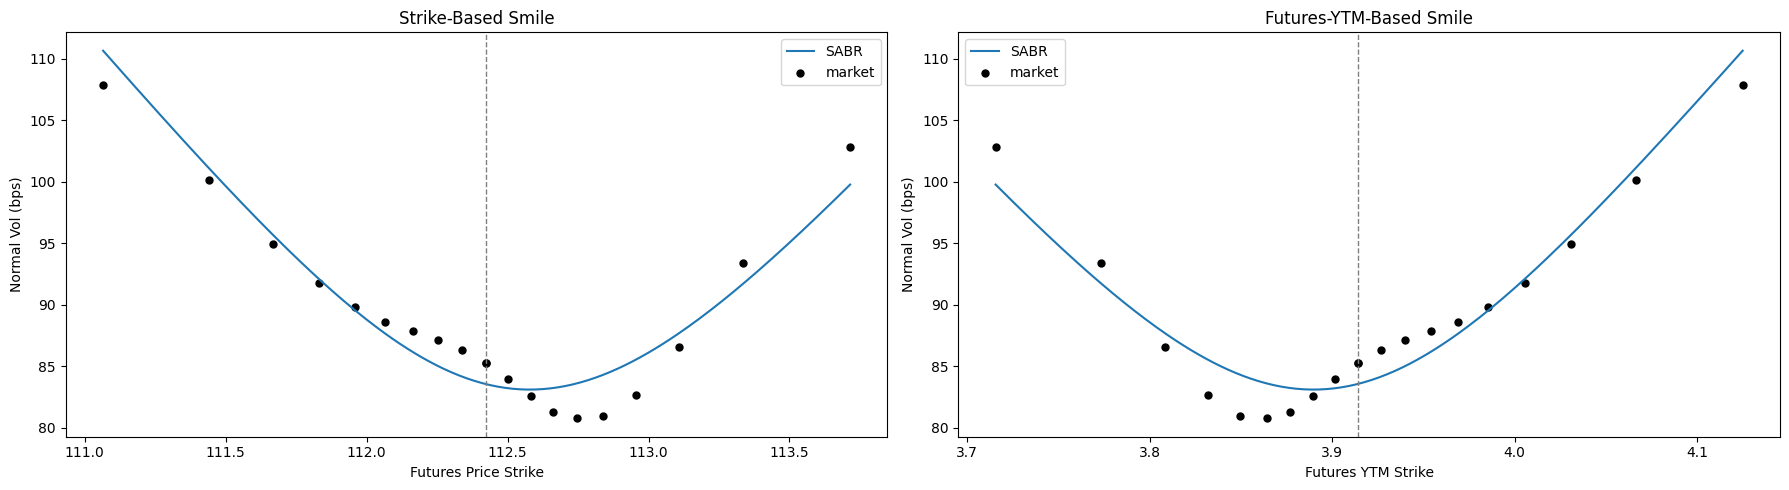

In [14]:
print(smile.params)
print("forward price:", smile.params.forward_price)
print("forward futures ytm:", smile.params.forward_futures_ytm)
print("fv01:", smile.fv01)

# strike-based grid
price_strikes = np.linspace(
    min(p.strike_price for p in smile.points),
    max(p.strike_price for p in smile.points),
    200,
)
price_vols_bps = smile.normal_vol(price_strikes, strike_space="price", vol_units="bps")

# YTM-based grid
ytm_strikes = np.linspace(
    min(p.strike_futures_ytm for p in smile.points),
    max(p.strike_futures_ytm for p in smile.points),
    200,
)
ytm_vols_bps = smile.normal_vol(ytm_strikes, strike_space="futures_ytm", vol_units="bps")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(price_strikes, price_vols_bps, label="SABR")
axes[0].scatter([p.strike_price for p in smile.points], [p.iv_normal_bps for p in smile.points], s=25, c="black", label="market")
axes[0].axvline(smile.params.forward_price, ls="--", lw=1, c="gray")
axes[0].set_title("Strike-Based Smile")
axes[0].set_xlabel("Futures Price Strike")
axes[0].set_ylabel("Normal Vol (bps)")
axes[0].legend()

axes[1].plot(ytm_strikes, ytm_vols_bps, label="SABR")
axes[1].scatter([p.strike_futures_ytm for p in smile.points], [p.iv_normal_bps for p in smile.points], s=25, c="black", label="market")
axes[1].axvline(smile.params.forward_futures_ytm, ls="--", lw=1, c="gray")
axes[1].set_title("Futures-YTM-Based Smile")
axes[1].set_xlabel("Futures YTM Strike")
axes[1].set_ylabel("Normal Vol (bps)")
axes[1].legend()

plt.tight_layout()
plt.show()


SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.04609783611116788, `time`: 0.0210s


(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x1fdee609810>])

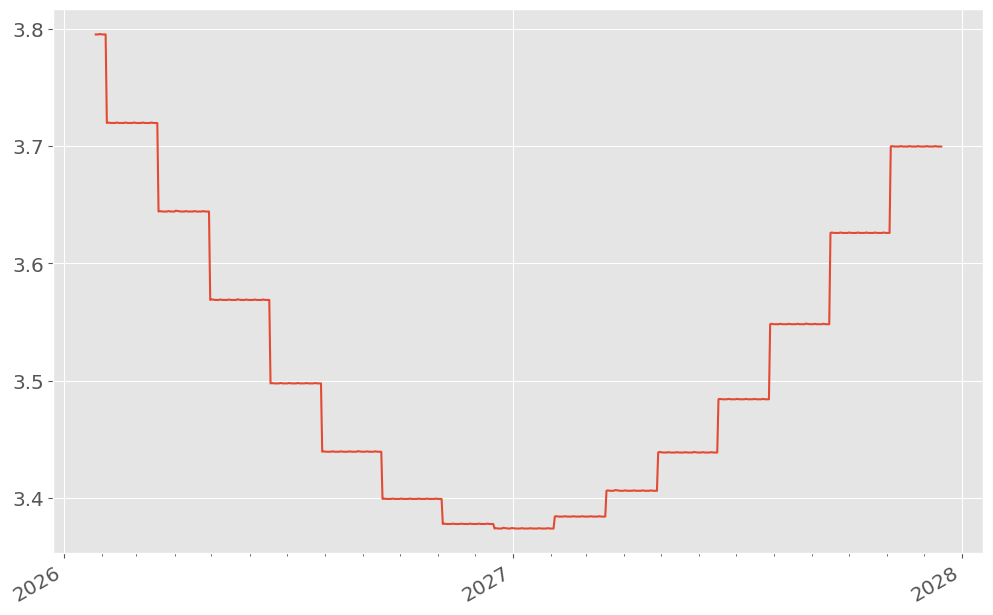

In [4]:
# ts = NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00))
# curve, solver = bc_stirf_curve.build_curve(curve_name="USD-OIS-Q8xM12", timestamp=ts, kwargs=dict(force_refresh=False))
# curve, solver = bc_stirf_curve.build_curve(curve_name="USD-SOFR-1D-Q12x3", timestamp=ts, kwargs=dict(force_refresh=True))

# timestamps = ql_cal_date_range(
#     ql.UnitedStates(ql.UnitedStates.GovernmentBond),
#     start=NY_tz.localize(datetime.datetime(2026, 2, 17, 1, 50)),
#     end=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
#     freq="1min",
# )
# timestamps = pd.date_range(NY_tz.localize(datetime.datetime(2026, 2, 17, 16, 50)), NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)), freq="1min").to_list()

curves = bc_stirf_curve.build_curve(
    # curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
    curve_name="GBP-SONIA-Q12STIRT",
    timestamp=LDN_tz.localize(datetime.datetime(2026, 1, 27, 17, 00)),
    # timestamp=NY_tz.localize(datetime.datetime(2026, 1, 27, 7, 29)),
    # timestamp="live",
    # kwargs={
    #     "force_refresh": True,
    #     "cache_full_intraday_fetch": True,
    # },
)
curves.plot("1d")

SUCCESS: `conv_tol` reached after 3 iterations (levenberg_marquardt), `f_val`: 0.0098368048689759, `time`: 0.0135s


(<Figure size 640x480 with 1 Axes>,
 <Axes: >,
  <matplotlib.lines.Line2D at 0x171f9e54f50>])

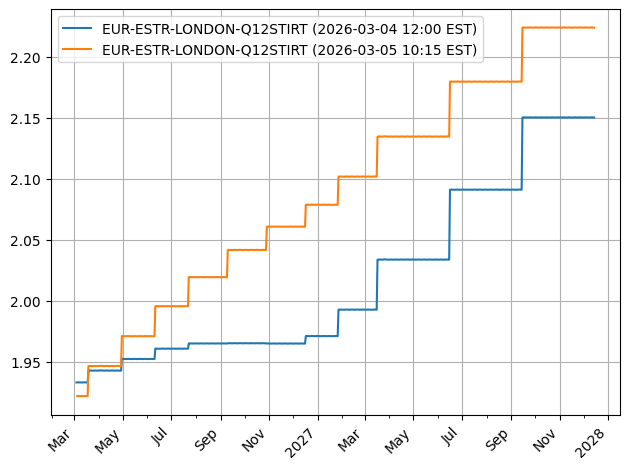

In [9]:
plot_overnight_forward_curves(
    curves=[
        # bc_stirf_curve.build_curve(
        #     curve_name="USD-SOFR-1D-Q12xM12STIRT",
        #     timestamp=NY_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
        #     # timestamp="live",
        #     # kwargs={
		# 	# 	"force_refresh": True,
		# 	#     "cache_full_intraday_fetch": True,
        #     # },
        # ),
        # bc_stirf_curve.build_curve(
        #     curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
        #     timestamp=NY_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
        # ),
        # bc_stirf_curve.build_curve(
            # curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
        #     timestamp=NY_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
		# 	# kwargs={
		# 	# 	"force_refresh": True,
		# 	# },
        # ),
        bc_stirf_curve.build_curve(
            # curve_name="USD-OIS-Q12xM12STIRT",
            # curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
            # curve_name="GBP-SONIA-Q12STIRT",
            curve_name="EUR-ESTR-LONDON-Q12STIRT",
            timestamp=LDN_tz.localize(datetime.datetime(2026, 3, 4, 17, 00)),
        ),
        bc_stirf_curve.build_curve(
            # curve_name="USD-OIS-Q12xM11STIRT",
            # curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
            curve_name="EUR-ESTR-LONDON-Q12STIRT",
            # curve_name="GBP-SONIA-Q12STIRT",
            # timestamp=NY_tz.localize(datetime.datetime(2026, 3, 1, 8, 29)),
            timestamp="live",
        ),
    ]
)

In [10]:
fomc_dated_ois = {
    "mar26": (rl.dt(2026, 3, 18), rl.dt(2026, 4, 29)),
    "apr26": (rl.dt(2026, 4, 29), rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 10, 28)),
    "oct26": (rl.dt(2026, 10, 28), rl.dt(2026, 12, 9)),
    # "dec26": (rl.dt(2026, 12, 9), rl.dt(2027, 1, 27)),
}

ecb_dated_ois = {
    "mar26": (rl.dt(2026, 3, 25), rl.dt(2026, 5, 6)),
    "may26": (rl.dt(2026, 5, 6),  rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 11, 4)),
    "nov26": (rl.dt(2026, 11, 4), rl.dt(2026, 12, 23)),
}


def build_meeting_dated_ois(meeting: str, meeting_dates: dict, rl_curve: rl.Curve, risk=None, notional=None, rl_irs_swap_kargs={}):
    assert risk is not None or notional is not None, "Must pass in `risk` or `notional`"

    if risk is not None:
        unit_delta = rl.IRS(
            effective=meeting_dates[meeting][0], termination=meeting_dates[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=1
        ).analytic_delta(rl_curve)
        notional = risk / unit_delta

    fomc_swap = rl.IRS(
        effective=meeting_dates[meeting][0], termination=meeting_dates[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=notional, **rl_irs_swap_kargs
    )
    return fomc_swap



meeting_curve =  bc_stirf_curve.build_curve(
	# curve_name="USD-OIS-Q12xM11STIRT",
	# curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
	curve_name="EUR-ESTR-LONDON-Q12STIRT",
	# curve_name="GBP-SONIA-Q12STIRT",
	# timestamp=NY_tz.localize(datetime.datetime(2026, 3, 1, 8, 29)),
	timestamp="live",
)
# meeting_dates = fomc_dated_ois
meeting_dates = ecb_dated_ois 
for key in meeting_dates.keys():
    print(key, build_meeting_dated_ois(meeting=key, meeting_dates=meeting_dates, rl_curve=meeting_curve, notional=1).rate().real)

# for key in ecb_dated_ois.keys():
#     print(key, build_ecb_ois(meeting=key, rl_curve=curves, notional=1).rate().real)

SUCCESS: `conv_tol` reached after 3 iterations (levenberg_marquardt), `f_val`: 0.0098368048689759, `time`: 0.0138s
mar26 1.9519966842050454
may26 1.9765399911914219
jun26 2.001084168673284
jul26 2.0247112637884186
sep26 2.046694994643234
nov26 2.0657098111386296


In [123]:
mdp = STIRFutureMDP(source="BARCHART_STIRF-RL")

# must be timezone-aware
chi_tz = pytz.timezone("America/Chicago")
ts = chi_tz.localize(datetime.datetime(2026, 2, 20, 17, 00))

mdp.get_data(
    {
        "symbols": ["SERCM1"],
        # "timestamp": ts,
        "timestamp": "live",
        # "force_refresh": True,
        # "cache_full_intraday_fetch": True,
    }
)

FETCHING SESSION TOKENS...: 100%|██████████| 2/2 [00:00<00:00,  2.00it/s]


{'SERCM1': [RLSTIRFuturePricer(_curve='USD-SOFR-1D', _rl_stirf_id='SR1G26', _reference_date=datetime.date(2026, 2, 27), _effective_date=datetime.date(2026, 2, 2), _maturity_date=datetime.date(2026, 3, 2), _price=96.335, _rate=3.6650000000000063, _contracts=1, _notional=1000000, _meta_data={'symbol': 'SR1G26', 'price': 96.335, 'timestamp': '2026-02-27T15:00:57.593990+00:00', 'schema': 1, 'fixings': USD-SOFR-1D
  2018-04-02    1.80
  2018-04-03    1.83
  2018-04-04    1.74
  2018-04-05    1.75
  2018-04-06    1.75
                ... 
  2026-02-20    3.66
  2026-02-23    3.66
  2026-02-24    3.67
  2026-02-25    3.67
  2026-02-26    3.67
  Name: Fixing, Length: 1974, dtype: float64})]}

In [32]:
bcf = BarchartFetcher()

# USD/CAD FX Forward Tickers

dollar_cad_on_fwd = "USDCAD.O"        # Overnight
dollar_cad_tom_fwd = "USDCAD.A"       # Tomorrow
dollar_cad_spot_fwd = "USDCAD.S"      # Spot
dollar_cad_1w_fwd = "USDCAD.B"        # 1-Week
dollar_cad_2w_fwd = "USDCAD.C"        # 2-Week
dollar_cad_3w_fwd = "USDCAD.D"        # 3-Week
dollar_cad_1m_fwd = "USDCAD.E"        # 1-Month
dollar_cad_2m_fwd = "USDCAD.G"        # 2-Month
dollar_cad_3m_fwd = "USDCAD.H"        # 3-Month
dollar_cad_4m_fwd = "USDCAD.J"        # 4-Month
dollar_cad_5m_fwd = "USDCAD.K"        # 5-Month
dollar_cad_6m_fwd = "USDCAD.M"        # 6-Month
dollar_cad_7m_fwd = "USDCAD.N"        # 7-Month
dollar_cad_8m_fwd = "USDCAD.Q"        # 8-Month
dollar_cad_9m_fwd = "USDCAD.U"        # 9-Month
dollar_cad_10m_fwd = "USDCAD.V"       # 10-Month
dollar_cad_11m_fwd = "USDCAD.X"       # 11-Month
dollar_cad_1y_fwd = "USDCAD.1"        # 1-Year
dollar_cad_2y_fwd = "USDCAD.2"        # 2-Year
dollar_cad_3y_fwd = "USDCAD.3"        # 3-Year


df = bcf.barchart_timeseries_api(
    barchart_symbols=[dollar_cad_1w_fwd],
    start_date=NY_tz.localize(datetime.datetime(2026, 2, 17, 7, 00)),
    end_date=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
    interval=1,
)[dollar_cad_1w_fwd]

df

FETCHING INTRADAY DATA FROM BARCHART...: 100%|██████████| 1/1 [00:00<00:00,  2.18it/s]


,Open,High,Low,Close,Volume
Date,,,,,
2026-02-17 07:00:00-05:00,-3.9925,-3.9925,-3.9925,-3.9925,0
2026-02-17 07:01:00-05:00,-3.9925,-3.9925,-3.9925,-3.9925,0
2026-02-17 07:02:00-05:00,-3.9925,-3.9925,-3.9930,-3.9930,0
2026-02-17 07:03:00-05:00,-3.9930,-3.9930,-3.9930,-3.9930,0
2026-02-17 07:04:00-05:00,-3.9930,-3.9930,-3.9930,-3.9930,0
...,...,...,...,...,...
2026-02-17 16:46:00-05:00,-3.9940,-3.9940,-3.9940,-3.9940,0
2026-02-17 16:47:00-05:00,-3.9940,-3.9940,-3.9940,-3.9940,0
2026-02-17 16:48:00-05:00,-3.9940,-3.9940,-3.9940,-3.9940,0


SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.0077315050425418, `time`: 0.1431s
SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.007916590264343258, `time`: 0.0239s


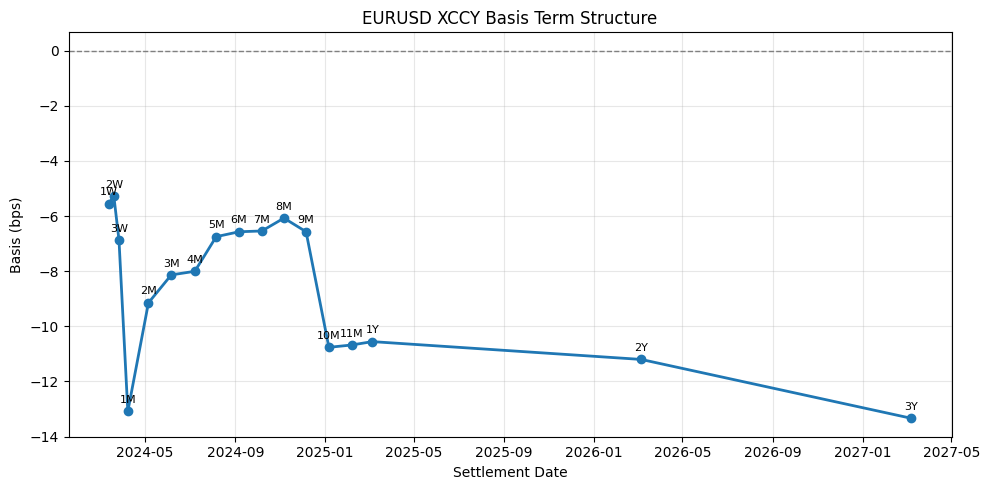

,tenor,settlement_date,basis_bps
3,1W,2024-03-13,-5.553668
4,2W,2024-03-20,-5.270464
5,3W,2024-03-27,-6.870113
6,1M,2024-04-08,-13.085823
7,2M,2024-05-06,-9.147268
8,3M,2024-06-06,-8.134355
9,4M,2024-07-08,-8.003425
10,5M,2024-08-06,-6.747418
11,6M,2024-09-06,-6.569144
12,7M,2024-10-07,-6.540329


In [17]:
from MDP.STIRFutures.FXForwardMDP import FXForwardMDP

mdp = FXForwardMDP(source="BARCHART_FXFWD-RL")

req = {
    "symbols": ["EURUSD"],  # full O..3Y strip
    "timestamp": LDN_tz.localize(datetime.datetime(2024, 3, 4, 17, 00)),  
    "curve_profile_key": "eurusd_sofr_estr_ldn",  
    "force_refresh": False,
    "window_minutes": 1,
}
out = mdp.get_data(req)

strip = next(iter(out.values())) 

rows = []
for p in strip:
    rows.append(
        {
            "tenor": p.tenor(),
            "symbol": p.symbol(),
            "settlement_date": p.settlement_date(),
            "basis_bps": p.basis_bps(),
        }
    )

df = pd.DataFrame(rows).sort_values("settlement_date")

# keep only calibrated tenors (O/A/S are typically None by design)
basis_df = df.dropna(subset=["basis_bps"]).copy()

if basis_df.empty:
    raise RuntimeError(f"No basis points available. curve_error={strip[0].meta().get('curve_error')}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(basis_df["settlement_date"], basis_df["basis_bps"], marker="o", lw=2)
ax.axhline(0.0, color="gray", lw=1, ls="--")
ax.set_title(f"{next(iter(out.keys()))} XCCY Basis Term Structure")
ax.set_xlabel("Settlement Date")
ax.set_ylabel("Basis (bps)")
ax.grid(alpha=0.3)

# optional: annotate tenor labels
for _, r in basis_df.iterrows():
    ax.annotate(r["tenor"], (r["settlement_date"], r["basis_bps"]), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)

plt.tight_layout()
plt.show()

basis_df[["tenor", "settlement_date", "basis_bps"]]

In [34]:
out

{'EURUSD': [RLFXForwardPricer(_pair='EURUSD', _symbol='EURUSD.O', _tenor='ON', _settlement_date=datetime.date(2026, 2, 18), _quote_timestamp=datetime.datetime(2026, 2, 17, 17, 0, tzinfo=datetime.timezone.utc), _spot=1.18296, _points_raw=0.58, _points_decimal=5.7999999999999994e-05, _forward_rate=1.183018, _basis_bps=None, _fx_rates=<rl.FXRates:[eur,usd] at 0x295c16bacf0>, _fx_forwards=<rl.FXForwards:[eur,usd] at 0x295c16ba900>, _meta_data={'schema': 1, 'source': 'BARCHART_FXFWD-RL', 'symbol': 'EURUSD.O', 'pair': 'EURUSD', 'suffix': 'O', 'tenor': 'ON', 'spot_symbol': '^EURUSD', 'spot_lag_bdays': 2, 'settlement_calendar': 'nyc,tgt', 'curve_profile_key': 'eurusd_sofr_estr_ldn', 'curve_names': {'EUR': 'EUR-ESTR-LONDON-Q12STIRT', 'USD': 'USD-SOFR-1D-Q12xM12STIRT'}, 'curve_error': None, 'spot_timestamp': datetime.datetime(2026, 2, 17, 17, 0, tzinfo=datetime.timezone.utc), 'quote_timestamp': datetime.datetime(2026, 2, 17, 17, 0, tzinfo=datetime.timezone.utc)}),
  RLFXForwardPricer(_pair='EURU

In [ ]:
import datetime as dt

from MDP.IRSwaptions.IRSwaptionMDP import IRSwaptionMDP
from Query.Base.query_resolution import resolve_query
from Query.IRSwaptions import IRSwaptionQuery, IRSwaptionStructure, IRSwaptionValue

# Requires env vars for GS vol provider:
#   GS_CLIENT_ID
#   GS_CLIENT_SECRET

as_of = dt.date(2024, 2, 23)
curve_name = "USD-SOFR-1D"

# 1) Build market context from MDP (curve + vol + engine)
mdp = IRSwaptionMDP(source="GSQUANT-QL")
ctx = mdp.get_pricer(
    {
        "endpoint": "swaption_snapshot",
        "curve_name": curve_name,
        "timestamp": as_of,
        "surface_type": "atmf_normal",
        "ignore_cache": False,
    }
)

# # 2) Build a 1Yx10Y Query (payer here; switch to RECEIVER if needed)
# q = IRSwaptionQuery(
#     curve=curve_name,
#     expiry="1Y",
#     tail="5Y",
#     structure=IRSwaptionStructure.PAYER,
#     value=IRSwaptionValue.SPOT_NPV,
#     strike="ATMF",
#     side="buy",
#     structure_kwargs={"notional": 100_000_000},
# )

# # 3) Resolve + price
# q_eff = resolve_query(q, timestamp=as_of, pricer_or_curve=ctx)
# package, weights = q_eff.resolve_package(pricer_or_curve=ctx)
# vmap = q_eff.build_value_map(pricer_or_curve=ctx, package=package, risk_weights=weights)

# spot_npv = float(vmap.apply(value=IRSwaptionValue.SPOT_NPV))
# fwd_npv = float(vmap.apply(value=IRSwaptionValue.FWD_PREM))
# delta = float(vmap.apply(value=IRSwaptionValue.DELTA))
# vega_01 = float(vmap.apply(value=IRSwaptionValue.VEGA_01))
# nvol = float(vmap.apply(value=IRSwaptionValue.NVOL))

# print("SPOT_NPV:", spot_npv)
# print("FWD_NPV:", fwd_npv)
# print("DELTA:", delta)
# print("VEGA_01:", vega_01)
# print("NVOL (bps):", nvol)

# q = IRSwaptionQuery(
#     curve=curve_name,
#     expiry="1Y",
#     tail="1Yx10Y",
#     structure=IRSwaptionStructure.PAYER,   # or RECEIVER
#     value=IRSwaptionValue.FWD_NVOL,
#     strike="ATMF",
#     side="buy",
#     structure_kwargs={"notional": 100_000_000},
# )

# # ---- resolve and price ----
# q_eff = resolve_query(q, timestamp=as_of, pricer_or_curve=ctx)
# package, weights = q_eff.resolve_package(pricer_or_curve=ctx)
# vmap = q_eff.build_value_map(pricer_or_curve=ctx, package=package, risk_weights=weights)

# # Forward vol from traded midcurve vol
# fwd_nvol_mkt = float(vmap.apply(IRSwaptionValue.FWD_NVOL))

# # Forward vol using fair midcurve vol from JPM-style decomposition
# fwd_nvol_fair = float(
#     vmap.apply(
#         IRSwaptionValue.FWD_NVOL,
#         use_fair_midcurve=True,
#         rho=1.0,   # adjust if you want non-100% correlation assumption
#     )
# )

# # Optional: fair midcurve implied itself
# midcurve_fair_nvol = float(
#     vmap.apply(
#         IRSwaptionValue.MIDCURVE_FAIR_NVOL,
#         rho=1.0,
#     )
# )

# print("1Y x (1Yx10Y) midcurve")
# print("FWD_NVOL (from traded midcurve), bps:", fwd_nvol_mkt)
# print("FWD_NVOL (using fair midcurve), bps:", fwd_nvol_fair)
# print("MIDCURVE_FAIR_NVOL, bps:", midcurve_fair_nvol)

1Y x (1Yx10Y) midcurve
FWD_NVOL (from traded midcurve), bps: 102.4765406802325
FWD_NVOL (using fair midcurve), bps: 106.82416646374914
MIDCURVE_FAIR_NVOL, bps: 104.02599824123789


In [16]:
q = IRSwaptionQuery(
    curve=curve_name,
    expiry="1Y",
    tail="5Y",
    structure=IRSwaptionStructure.STRADDLE,
    value=IRSwaptionValue.SPOT_NPV,
    strike="ATMF",
    side="buy",
    structure_kwargs={"notional": 100_000_000},
)

# 3) Resolve + price
q_eff = resolve_query(q, timestamp=as_of, pricer_or_curve=ctx)
package, weights = q_eff.resolve_package(pricer_or_curve=ctx)
vmap = q_eff.build_value_map(pricer_or_curve=ctx, package=package, risk_weights=weights)

spot_npv = float(vmap.apply(value=IRSwaptionValue.SPOT_NPV))
fwd_npv = float(vmap.apply(value=IRSwaptionValue.FWD_PREM))
delta = float(vmap.apply(value=IRSwaptionValue.DELTA))
vega_01 = float(vmap.apply(value=IRSwaptionValue.VEGA_01))
nvol = float(vmap.apply(value=IRSwaptionValue.NVOL))

print("SPOT_NPV:", spot_npv)
print("FWD_NPV:", fwd_npv)
print("DELTA:", delta)
print("VEGA_01:", vega_01)
print("NVOL (bps):", nvol)


SPOT_NPV: 4042117.1898848214
FWD_NPV: 4.251538945815017
DELTA: 8.326672684688674e-16
VEGA_01: 34537.22480569425
NVOL (bps): 117.0365370299928


In [14]:
float(vmap.apply(value=IRSwaptionValue.THETA_1D))

0.0